<font color = green >

## Home Task: Implement K-means algorithm

</font>


In [265]:
import matplotlib.pyplot as plt
import numpy as np

<font color = green >

###  Data 

</font>



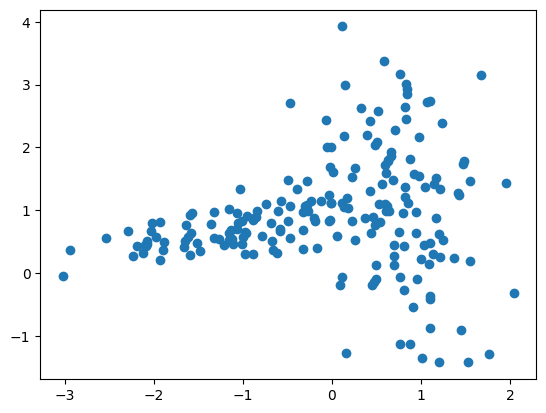

In [266]:
from sklearn.datasets import make_classification
Xc_2,_= make_classification(n_samples=200,
                                    n_features=2,
                                    n_informative=2,
                                    n_redundant=0,
                                    random_state=0,
                                    n_clusters_per_class=1,
                                    class_sep = 0.8)
plt.figure()
plt.scatter  (Xc_2[:,0], Xc_2[:,1])

### Implementatiion

#### 1) Initialize $K$ centroids 

In [292]:
K = 4
colors = np.array(['red', 'green', 'blue', 'orange'])

In [293]:
def plot_data(x = Xc_2[:,0], y = Xc_2[:,1], K = 4, centroids = None, closest_centroids = None):
    plt.figure()
    if closest_centroids is not None:
        plt.scatter(x, y, c=colors[closest_centroids])
    else:
        plt.scatter(x, y)
    if centroids is not None:
        for i in range(K):
            plt.scatter(centroids[i,0], centroids[i,1], c=colors[i], marker='X', s=200)

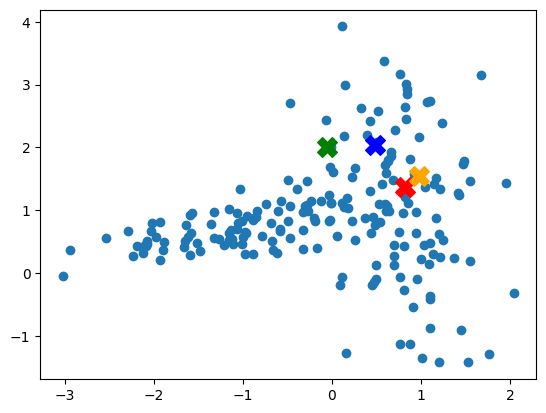

In [294]:
def init_centroids(data, K):
    return data [np.random.choice(len(data), K)] 
centroids = init_centroids(Xc_2, K)
plot_data(centroids = centroids)

### 2) Assign every point to closest centroid 

In [295]:
def compute_distances(data, centroids):
    distances = np.zeros((len(data), len(centroids)))
    for k in range(len(centroids)):
        distances[:, k] = np.linalg.norm(data - centroids[k], axis=1)
    return distances
distances = compute_distances(Xc_2, centroids)
distances[:5]

array([[2.49740198, 3.26832029, 3.19105244, 2.68055324],
       [1.13342637, 0.95325554, 1.2252511 , 1.33871038],
       [0.1818416 , 0.90146286, 0.58377872, 0.29771026],
       [0.60003076, 1.66154654, 1.34585129, 0.69792605],
       [1.99770819, 1.65308856, 2.04875432, 2.2101393 ]])

In [296]:
closest_centroids = np.argmin(distances, axis=1)
closest_centroids

array([0, 1, 0, 0, 1, 1, 2, 1, 1, 2, 0, 0, 2, 0, 1, 1, 1, 0, 1, 3, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 3, 1, 1, 1, 1, 0, 0, 1, 1, 2, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 3, 1, 1, 3, 1, 1, 0, 2, 0, 1, 0, 1, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 2, 2, 1, 0, 1, 1, 1, 1, 0, 1, 2,
       0, 2, 1, 2, 2, 2, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 3,
       1, 2, 1, 3, 1, 0, 2, 2, 1, 2, 0, 2, 2, 1, 0, 0, 1, 3, 1, 1, 0, 1,
       0, 1, 1, 0, 0, 3, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1,
       0, 1, 2, 1, 0, 2, 0, 1, 0, 1, 1, 3, 0, 2, 1, 1, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 3, 2, 0, 0, 3, 1, 2, 1, 0, 0, 2, 1, 1, 3, 2, 2, 0,
       0, 3], dtype=int64)

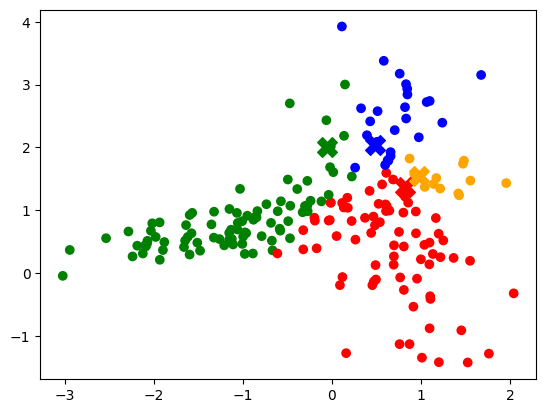

In [297]:
plot_data(centroids = centroids, closest_centroids = closest_centroids)

### 3) Compute new centroids as means of samples assigned to corresponding centroid

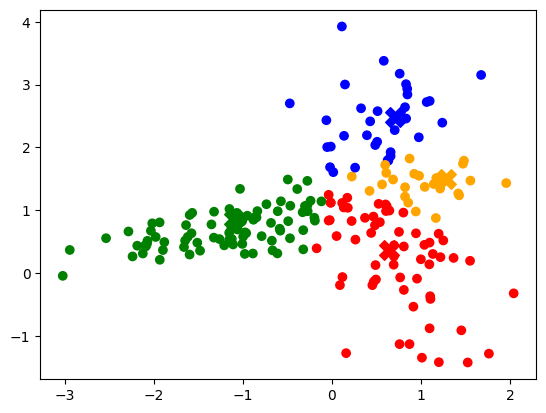

In [298]:
def update_centroids(centroids, closest_centroids, K):

    new_centroids = np.zeros_like(centroids)
    for k in range(K):
        points = Xc_2[closest_centroids == k]
        if len(points) > 0:
            new_centroids[k] = points.mean(axis=0)
        else:
            new_centroids[k] = centroids[k]
    return new_centroids

new_centroids = update_centroids(centroids, closest_centroids, K)
New_distances = compute_distances(Xc_2, new_centroids)
new_closest_centroids = np.argmin(New_distances, axis=1)
plot_data(centroids = new_centroids, closest_centroids = new_closest_centroids)

### 4) Implement cost $J = \frac{1}{m}\underset{i}{\sum}(d^{(i)})^{2}$ where $d^{(i)}$ is distance from sample $x^{(i)}$ to assigned centroid $c^{(i)}$

In [300]:
def compute_J(data, centroids, closest_centroids):
    distances = compute_distances(data, centroids)
    return 1/len(data)*np.sum(np.array([distances[i, closest_centroids[i]] for i in range(len(data))])**2)

J = compute_J(Xc_2, centroids, closest_centroids)
J

2.1924454937012223

### 5) Iterate setps 2,3 till cost is stabile 

In [301]:
def k_means(data, K, max_iters=20, centroids=None, verbose=False):
    J_old = None
    iter = 0
    if centroids is None:
        centroids = init_centroids(data, K)
    start_centroids = centroids.copy()
    while iter < max_iters:
        distances = compute_distances(data, centroids)
        closest_centroids = np.argmin(distances, axis=1)
        J = compute_J(data, centroids, closest_centroids)
        if verbose:
            print(f'Iteration {iter}, J: {J}')
        if J_old and J_old <= J:
            break
        J_old = J
        iter += 1
        centroids = update_centroids(centroids, closest_centroids, K)
    return start_centroids, centroids, closest_centroids, J
    
        
k_means(Xc_2, K, verbose=True, centroids=centroids)

Iteration 0, J: 2.1924454937012223
Iteration 1, J: 0.6138112860763828
Iteration 2, J: 0.560004237555419
Iteration 3, J: 0.504294645886389
Iteration 4, J: 0.4795908842452807
Iteration 5, J: 0.4663382494843562
Iteration 6, J: 0.46435871914100246
Iteration 7, J: 0.46383720396920963
Iteration 8, J: 0.46383720396920963


(array([[ 0.82034231,  1.36774802],
        [-0.0534837 ,  2.00588694],
        [ 0.48596056,  2.03866478],
        [ 0.9777002 ,  1.5492486 ]]),
 array([[ 0.95709384, -0.24104829],
        [-1.34884513,  0.62507834],
        [ 0.5692831 ,  2.59347937],
        [ 0.45306552,  1.1911892 ]]),
 array([0, 3, 3, 3, 1, 1, 2, 1, 1, 2, 3, 0, 2, 3, 1, 1, 3, 0, 1, 3, 1, 0,
        3, 3, 0, 0, 1, 0, 1, 0, 3, 1, 1, 1, 1, 3, 0, 1, 1, 2, 1, 3, 3, 0,
        3, 1, 1, 3, 0, 3, 0, 0, 3, 1, 2, 3, 1, 1, 3, 2, 0, 1, 0, 1, 1, 3,
        1, 3, 1, 0, 0, 3, 1, 0, 1, 3, 3, 2, 3, 1, 0, 1, 1, 1, 2, 3, 3, 2,
        3, 2, 1, 2, 3, 2, 1, 0, 0, 2, 3, 2, 2, 1, 0, 3, 1, 1, 1, 1, 1, 3,
        1, 3, 1, 3, 1, 3, 2, 2, 1, 2, 3, 2, 2, 1, 0, 3, 1, 3, 3, 1, 3, 2,
        3, 3, 3, 0, 3, 3, 3, 0, 3, 3, 3, 1, 3, 0, 3, 1, 3, 1, 1, 0, 3, 1,
        3, 1, 3, 1, 0, 2, 3, 1, 0, 3, 1, 3, 0, 2, 1, 1, 3, 0, 3, 0, 0, 1,
        1, 0, 1, 1, 1, 3, 2, 3, 0, 3, 3, 2, 1, 3, 3, 2, 1, 1, 3, 3, 2, 0,
        1, 3], dtype=int64),
 0.4638372039

### 6) Select the best clustering (with the least cost) from 100 results computed with random centroid  initializations 

In [302]:
def best_init(data, K, n_init=100):
    best_J = None
    for i in range(n_init):
        start_centroids, centroids, closest_centroids, J = k_means(data, K)
        if best_J is None or J < best_J:
            best_centroids, best_J = start_centroids, J
    return best_centroids, centroids, closest_centroids, best_J

best_centroids, centroids, closest_centroids, best_J = best_init(Xc_2, K)
print(f'Best J: {best_J}')
print(f'Best centroids:\n{best_centroids}')


Best J: 0.4576916248652856
Best centroids:
[[ 1.0928623   0.14006749]
 [-1.51073367  0.48472872]
 [-0.83678414  0.98733728]
 [-0.17185091  0.39553557]]


### 7) Visualize results (clusters, centroids) for $K=4$

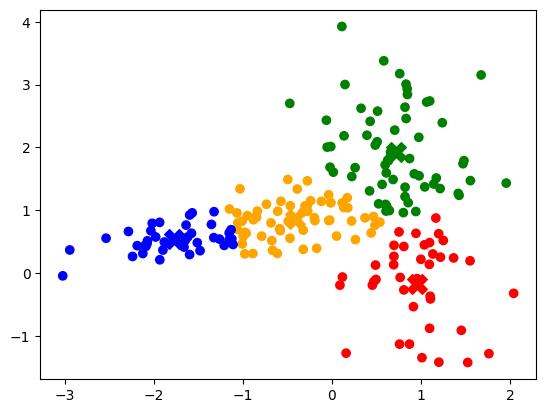

In [303]:
plot_data(centroids = centroids, closest_centroids = closest_centroids)

For $K$ = 2

Best J: 1.1198539724072398


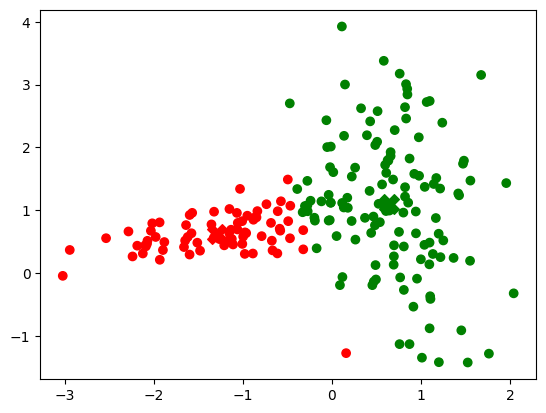

In [304]:
best_centroids, centroids, closest_centroids, best_J = best_init(Xc_2, K=2)
print(f'Best J: {best_J}')
plot_data(K = 2,centroids = centroids, closest_centroids = closest_centroids)